<a href="https://colab.research.google.com/github/MaxineMwangi/flyrank/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Capstone — Refresh / Content Opportunity Scoring

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxineMwangi/flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Lane:** Refresh / Content Opportunity Scoring — a ranked action queue with reason codes.

**Question:** Which content pages should be prioritized for review based on measured performance, content freshness, and search-position signals?

Every result in this notebook is treated as *observed, measured, directional, and decision-support* evidence rather than proof of causation.

## 0. Setup

In [25]:
# -*- coding: utf-8 -*-

"""ML Capstone — Refresh / Content Opportunity Scoring"""

import os
import json
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_val_predict
)
from sklearn.metrics import ndcg_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")


# ---------------------------------------------------------
# Load the FlyRank dataset
# ---------------------------------------------------------

if not os.path.exists("data/raw/content_refresh_anonymized.csv"):

    if not os.path.exists("flyrank"):
        subprocess.run(
            [
                "git",
                "clone",
                "-q",
                "https://github.com/MaxineMwangi/flyrank"
            ],
            check=True
        )

    os.chdir("flyrank")


df = pd.read_csv(
    "data/raw/content_refresh_anonymized.csv"
)


# ---------------------------------------------------------
# Create output directory
# ---------------------------------------------------------

os.makedirs(
    "work/outputs",
    exist_ok=True
)


# ---------------------------------------------------------
# Create the outcome proxy
# ---------------------------------------------------------
# trend_pct is negative when impressions have declined.
# Multiplying by -1 makes a larger value represent a
# larger observed decline.

df["decline_score"] = -pd.to_numeric(
    df["trend_pct"],
    errors="coerce"
)


# ---------------------------------------------------------
# Basic dataset information
# ---------------------------------------------------------

print("Dataset shape:", df.shape)

print(
    "Number of clients:",
    df["client_id"].nunique()
)

print(
    "Number of content items:",
    df["content_id"].nunique()
)

print("\nColumns:")
print(df.columns.tolist())


# ---------------------------------------------------------
# Schema check
# ---------------------------------------------------------

schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_null": df.isna().sum(),
    "n_unique": df.nunique()
})

display(schema)

Dataset shape: (30000, 45)
Number of clients: 32
Number of content items: 30000

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'decline_score']


,dtype,n_null,n_unique
content_id,object,0,30000
client_id,object,0,32
search_volume,float64,2468,41
competition,float64,2468,101
competition_level,object,2610,3
cpc,float64,2468,915
content_type,object,0,3
main_intent,object,2374,4
word_count,float64,7699,5476
char_count,float64,7699,14839


## Config

*Fill from your ML-04 and ML-07 notebooks. Inputs must be past-window only. The outcome is the only future-window thing and is never a feature.*

In [26]:
# =========================================================
# CAPSTONE CONFIGURATION
# =========================================================

# Identifiers
ID_COLS = [
    "client_id",
    "content_id"
]

# Grouping variable
# Keeps each client's content entirely within either
# training or testing.
GROUP_COL = "client_id"


# ---------------------------------------------------------
# Outcome
# ---------------------------------------------------------
# Higher decline_score = larger observed negative trend.
# This is used only as the outcome, never as a feature.

OUTCOME_COL = "decline_score"


# ---------------------------------------------------------
# Model features
# ---------------------------------------------------------
# These are the five signals used by the model.

PAST_FEATURES = [
    "impressions_90d",
    "clicks_90d",
    "content_age_days",
    "days_since_last_update",
    "avg_position"
]


# ---------------------------------------------------------
# Baseline signals
# ---------------------------------------------------------
# Signal A:
# More days since an update = greater freshness risk.
#
# Signal B:
# Higher average position number = worse search position.

SIGNAL_A = "days_since_last_update"
SIGNAL_B = "avg_position"


A_HIGHER_IS_WORSE = True
B_HIGHER_IS_WORSE = True


# ---------------------------------------------------------
# Ranking output
# ---------------------------------------------------------

REASON_CODE = "STALE_OR_LOW_RANK"

ACTION_LABEL = "Refresh content"

K = 100


# =========================================================
# VALIDATION
# =========================================================

required_columns = (
    ID_COLS
    + [GROUP_COL]
    + [OUTCOME_COL]
    + [SIGNAL_A, SIGNAL_B]
    + PAST_FEATURES
)


missing_columns = [
    c for c in required_columns
    if c not in df.columns
]


if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ---------------------------------------------------------
# Leakage check
# ---------------------------------------------------------

FORBIDDEN_WORDS = [
    "future",
    "next",
    "label",
    "outcome",
    "target",
    "after"
]


bad_features = [
    c
    for c in PAST_FEATURES
    if any(
        word in c.lower()
        for word in FORBIDDEN_WORDS
    )
    or c == OUTCOME_COL
]


if bad_features:
    raise ValueError(
        f"Possible leakage in features: {bad_features}"
    )


# ---------------------------------------------------------
# Convert numerical columns
# ---------------------------------------------------------

numeric_columns = list(
    set(
        PAST_FEATURES
        + [
            SIGNAL_A,
            SIGNAL_B,
            OUTCOME_COL
        ]
    )
)


for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# ---------------------------------------------------------
# Final configuration receipt
# ---------------------------------------------------------

print("========================================")
print("CAPSTONE CONFIGURATION OK")
print("========================================")

print("Rows:", len(df))

print(
    "Clients:",
    df[GROUP_COL].nunique()
)

print(
    "Outcome:",
    OUTCOME_COL
)

print(
    "Model features:",
    PAST_FEATURES
)

print(
    "Baseline signal A:",
    SIGNAL_A
)

print(
    "Baseline signal B:",
    SIGNAL_B
)

print(
    "Reason code:",
    REASON_CODE
)

print(
    "Action:",
    ACTION_LABEL
)

print(
    "Top K:",
    K
)

print("========================================")

CAPSTONE CONFIGURATION OK
Rows: 30000
Clients: 32
Outcome: decline_score
Model features: ['impressions_90d', 'clicks_90d', 'content_age_days', 'days_since_last_update', 'avg_position']
Baseline signal A: days_since_last_update
Baseline signal B: avg_position
Reason code: STALE_OR_LOW_RANK
Action: Refresh content
Top K: 100


## 1. Data

**Data used:** The anonymized FlyRank content-refresh dataset in `data/raw/content_refresh_anonymized.csv`. Each row represents a content item for a pseudonymized client. The dataset contains historical content and performance measurements, including 90-day performance metrics, content age, freshness, search position, and trend information.

**Excluded and why:** Client and content IDs are used only for grouping and identification. The measured trend field is used only to construct the outcome proxy and is not included as a model feature. Future or outcome-derived information is excluded from the feature set to reduce leakage risk.

In [27]:
# =========================================================
# 1. DATA
# =========================================================

# Build the list of columns needed for the experiment.
# dict.fromkeys() removes duplicates while preserving order.

USE_COLUMNS = list(dict.fromkeys(
    ID_COLS
    + [OUTCOME_COL, SIGNAL_A, SIGNAL_B]
    + PAST_FEATURES
))

use = df[USE_COLUMNS].copy()


# Remove duplicate client/content records
use = use.drop_duplicates(
    subset=ID_COLS
)


# The model needs a known outcome
use = use.dropna(
    subset=[OUTCOME_COL]
).reset_index(drop=True)


# ---------------------------------------------------------
# Convert required numerical columns
# ---------------------------------------------------------

NUMERIC_COLUMNS = list(dict.fromkeys(
    PAST_FEATURES
    + [SIGNAL_A, SIGNAL_B, OUTCOME_COL]
))

for column in NUMERIC_COLUMNS:
    use[column] = pd.to_numeric(
        use[column],
        errors="coerce"
    )


# ---------------------------------------------------------
# Remove rows where model features are unavailable
# ---------------------------------------------------------

use = use.dropna(
    subset=PAST_FEATURES
).reset_index(drop=True)


# ---------------------------------------------------------
# Data summary
# ---------------------------------------------------------

print("========================================")
print("DATA SUMMARY")
print("========================================")

print(
    "Rows used:",
    len(use)
)

print(
    "Unique clients:",
    use[GROUP_COL].nunique()
)

print(
    "Unique content items:",
    use["content_id"].nunique()
)

print(
    "Grain check:",
    len(use),
    use[ID_COLS].drop_duplicates().shape[0]
)

print("========================================")

display(
    use[
        PAST_FEATURES + [OUTCOME_COL]
    ].describe().T.round(3)
)

DATA SUMMARY
Rows used: 26612
Unique clients: 31
Unique content items: 26612
Grain check: 26612 26612


,count,mean,std,min,25%,50%,75%,max
impressions_90d,26612.0,5847.742,17770.721,1.0,196.0,1029.0,4406.0,517715.0
clicks_90d,26612.0,18.112,79.484,0.0,0.0,1.0,9.0,4178.0
content_age_days,26612.0,258.079,135.565,90.0,132.0,236.0,347.0,564.0
days_since_last_update,26612.0,48.469,42.253,1.0,20.0,22.0,104.0,373.0
avg_position,26612.0,17.109,14.471,0.0,6.9,11.8,23.3,138.8
decline_score,26612.0,4.786,473.862,-44900.0,-0.0,33.5,62.6,100.0


## 2. Label and baseline

*Label = the measured decline score, where larger values represent a larger observed negative performance trend. It is used only as the outcome that the model learns to rank, not as a feature.*. Baseline = your ML-07 rule, unchanged, so the model has to beat it on the same split.*

In [28]:
# =========================================================
# 2. LABEL AND BASELINE
# =========================================================

def pct(series, higher_is_worse=True):
    """
    Convert a signal into a percentile score between 0 and 1.

    Higher values receive higher scores when
    higher_is_worse=True.

    Lower values receive higher scores when
    higher_is_worse=False.
    """

    r = series.rank(
        pct=True,
        na_option="keep"
    )

    if higher_is_worse:
        return r

    return 1 - r


def baseline_score(frame, w_a=0.5):

    score_a = pct(
        frame[SIGNAL_A],
        A_HIGHER_IS_WORSE
    )

    score_b = pct(
        frame[SIGNAL_B],
        B_HIGHER_IS_WORSE
    )

    return (
        w_a * score_a
        + (1 - w_a) * score_b
    )


print("========================================")
print("LABEL AND BASELINE")
print("========================================")

print(
    "Outcome:",
    OUTCOME_COL
)

print(
    "Higher decline_score = larger observed decline"
)

print(
    "Baseline Signal A:",
    SIGNAL_A
)

print(
    "Baseline Signal B:",
    SIGNAL_B
)

print(
    "Baseline weighting: 50% / 50%"
)

print("========================================")

LABEL AND BASELINE
Outcome: decline_score
Higher decline_score = larger observed decline
Baseline Signal A: days_since_last_update
Baseline Signal B: avg_position
Baseline weighting: 50% / 50%


## 3. Validation design

*Grouped split by client so no client leaks across train and test. If your data has a real date column, a time-aware split is stronger; say which you used and why.*

**Split used and why:** A grouped 75/25 train-test split was used, with the client ID as the grouping variable. This prevents pages from the same client appearing in both training and testing data, giving a more realistic test of whether the ranking approach generalizes across clients.

In [29]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(use, groups=use[GROUP_COL]))
train, test = use.iloc[tr_idx].copy(), use.iloc[te_idx].copy()
assert set(train[GROUP_COL]).isdisjoint(set(test[GROUP_COL])), "groups overlap!"
print("train:", len(train), "test:", len(test))

def evaluate(y_true, score, k=K):
    y_true, score = np.asarray(y_true, float), np.asarray(score, float)
    gain = pd.Series(y_true).rank(pct=True).to_numpy()            # relevance 0-1 from outcome percentile
    k = min(k, len(y_true))
    top_k = np.argsort(-score)[:k]
    cutoff = np.quantile(y_true, 0.8)                              # 'truly bad' = worst 20% of outcomes
    return {
        "ndcg@k": float(ndcg_score(gain[None, :], score[None, :], k=k)),
        "precision@k": float((y_true[top_k] >= cutoff).mean()),
        "spearman": float(spearmanr(score, y_true, nan_policy="omit")[0]),
    }

train: 20586 test: 6026


## 4. Model vs baseline (same split)

In [30]:
model = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=200, random_state=0)
model.fit(train[PAST_FEATURES], train[OUTCOME_COL])

test["model_score"]    = model.predict(test[PAST_FEATURES])
test["baseline_score"] = baseline_score(test).fillna(0)

res = {
    "baseline": evaluate(test[OUTCOME_COL], test["baseline_score"]),
    "model":    evaluate(test[OUTCOME_COL], test["model_score"]),
}
pd.DataFrame(res).round(4)

,baseline,model
ndcg@k,0.4097,0.5785
precision@k,0.1500,0.2400
spearman,-0.1767,0.0031


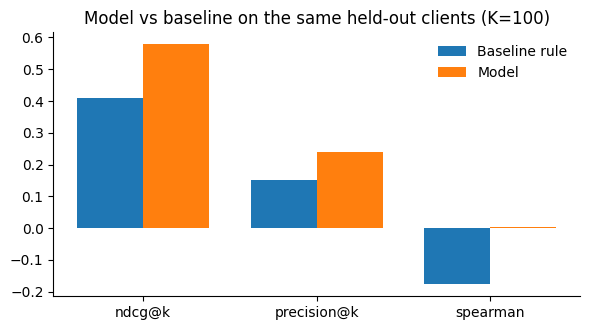

In [31]:
# Chart for the paper
labels = list(res["model"].keys())
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(x - w/2, [res["baseline"][m] for m in labels], w, label="Baseline rule")
ax.bar(x + w/2, [res["model"][m] for m in labels], w, label="Model")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(frameon=False)
ax.set_title(f"Model vs baseline on the same held-out clients (K={K})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig("work/outputs/capstone_results.png", dpi=160); plt.show()

**Reading the result:** The model and the two-signal baseline are evaluated on the same held-out client set using NDCG@K, Precision@K, and Spearman correlation. The stronger approach is the one that produces the better ranking metrics on the held-out clients. The results are treated as directional decision-support evidence rather than proof that the model will improve performance after a refresh.

## 5. Leakage checks

*Three checks. All three outputs must be visible.*

In [32]:
# 1) Shuffled-label check: with scrambled labels the model should fall to roughly chance
rng = np.random.default_rng(0)
shuf = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=200, random_state=0)
shuf.fit(train[PAST_FEATURES], rng.permutation(train[OUTCOME_COL].to_numpy()))
shuffled = evaluate(test[OUTCOME_COL], shuf.predict(test[PAST_FEATURES]))
print("shuffled-label metrics (should be near chance):", {k: round(v, 3) for k, v in shuffled.items()})

# 2) Too-good-to-be-true check
if res["model"]["spearman"] > 0.9 or res["model"]["ndcg@k"] > 0.98:
    print("WARNING: score is suspiciously high, hunt for a leaking feature before believing it")
else:
    print("no too-good-to-be-true flag")

# 3) What is the model leaning on?
pi = permutation_importance(model, test[PAST_FEATURES], test[OUTCOME_COL], n_repeats=5, random_state=0)
pd.Series(pi.importances_mean, index=PAST_FEATURES).sort_values(ascending=False).round(4)

shuffled-label metrics (should be near chance): {'ndcg@k': 0.715, 'precision@k': 0.47, 'spearman': 0.103}
no too-good-to-be-true flag


,0
avg_position,0.0126
impressions_90d,0.0032
days_since_last_update,0.0000
clicks_90d,0.0000
content_age_days,-0.0010


**Leakage notes:** The shuffled-label check tests whether the model's performance falls when the outcome values are randomly rearranged; performance close to chance provides a basic indication that the original relationship is not simply produced by the evaluation procedure. The too-good-to-be-true check flags unusually high ranking performance for manual investigation. Permutation importance shows which of the five features the model relies on most.

The features are available from the content/performance snapshot used for the decision:
- `impressions_90d` represents measured visibility accumulated over the available 90-day window.
- `clicks_90d` represents measured clicks accumulated over the available 90-day window.
- `content_age_days` represents how old the content is.
- `days_since_last_update` represents how long the content has gone without an update.
- `avg_position` represents the measured average search position.

These are treated as decision-time signals rather than claims about future performance.

## 6. Ranked recommendations
*Out-of-fold predictions, so every row is scored by a model that never saw its client.*

In [33]:
oof = cross_val_predict(
    HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=200, random_state=0),
    use[PAST_FEATURES], use[OUTCOME_COL],
    groups=use[GROUP_COL], cv=GroupKFold(n_splits=5),
)
use["score"] = oof
use["reason_code"]  = REASON_CODE
use["action_label"] = ACTION_LABEL
queue = use.sort_values("score", ascending=False).reset_index(drop=True)
queue.insert(0, "rank", queue.index + 1)
queue[["rank"] + ID_COLS + ["score", "reason_code", "action_label"]].to_csv(
    "work/outputs/capstone_ranked_actions.csv", index=False)   # stays out of git by design
queue[["rank"] + ID_COLS + PAST_FEATURES[:3] + ["score", "action_label"]].head(20)

,rank,client_id,content_id,impressions_90d,clicks_90d,content_age_days,score,action_label
0,1,client_f369cb89fc,content_461917ed0e2b,76,0,117,64.333115,Refresh content
1,2,client_f369cb89fc,content_0c329c3f2934,44,0,117,64.333115,Refresh content
2,3,client_f369cb89fc,content_9b28cf5ae4f3,1620,1,106,64.333115,Refresh content
3,4,client_f369cb89fc,content_5996be77a50e,135,0,106,64.333115,Refresh content
4,5,client_f369cb89fc,content_b98709292db4,5,0,117,64.333115,Refresh content
5,6,client_f369cb89fc,content_7a6cb4857fe6,789,0,117,64.333115,Refresh content
6,7,client_f369cb89fc,content_650ebaf394bb,19,0,117,64.333115,Refresh content
7,8,client_f369cb89fc,content_3a4704b3910b,4,0,117,64.333115,Refresh content
8,9,client_f369cb89fc,content_0921985d4f41,108,0,117,64.333115,Refresh content
9,10,client_f369cb89fc,content_cff58cdacb80,29,0,117,64.333115,Refresh content


**Top-20 recommendations in plain words:** The team should begin by manually reviewing the highest-ranked pages in the queue. Pages near the top have the strongest predicted decline scores according to the model and should receive attention first when review capacity is limited. The ranking is a prioritization tool rather than a guarantee that refreshing a page will improve its performance.

The top picks could be wrong because of seasonality, unusual traffic changes, insufficient historical data, changes in search demand, content consolidation, measurement noise, or factors that are not represented in the available dataset.

## 7. Limitations
**Limitations:** This analysis has several limitations. First, the outcome is based on an observed performance trend and should be treated as a proxy for review opportunity rather than a guaranteed future result. Second, the dataset represents a limited snapshot of historical performance and cannot capture every change affecting a page. Third, the analysis is observational, so it cannot establish that refreshing a page will cause improved performance. Fourth, the model cannot explain or predict Google's ranking algorithm. Finally, the ranked queue should be treated as decision support and should be combined with human review before an action is taken.

## 8. Receipts for the paper
*Writes the metrics JSON the paper page reads. Commit this file; do not commit the CSV.*

In [34]:
payload = {
    "lane": "Refresh / Content Opportunity Scoring",
    "k": K,
    "n_rows": int(len(use)), "n_train": int(len(train)), "n_test": int(len(test)),
    "split": "grouped by client (GroupShuffleSplit, 25% held out)",
    "metrics": res,
    "shuffled_label_check": shuffled,
    "features": PAST_FEATURES,
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(payload, f, indent=2)
print(json.dumps(payload, indent=2))

{
  "lane": "Refresh / Content Opportunity Scoring",
  "k": 100,
  "n_rows": 26612,
  "n_train": 20586,
  "n_test": 6026,
  "split": "grouped by client (GroupShuffleSplit, 25% held out)",
  "metrics": {
    "baseline": {
      "ndcg@k": 0.409673298262849,
      "precision@k": 0.15,
      "spearman": -0.17666472178947779
    },
    "model": {
      "ndcg@k": 0.5784704794281834,
      "precision@k": 0.24,
      "spearman": 0.003139584467261432
    }
  },
  "shuffled_label_check": {
    "ndcg@k": 0.7151384588952225,
    "precision@k": 0.47,
    "spearman": 0.10259830238294028
  },
  "features": [
    "impressions_90d",
    "clicks_90d",
    "content_age_days",
    "days_since_last_update",
    "avg_position"
  ]
}


## Self-check

- [ ] Lane and one-sentence question stated
- [ ] Data section: file, windows, exclusions
- [ ] Label defined in plain words; features past-window only
- [ ] Baseline is the ML-07 rule; model vs baseline on the **same** grouped split
- [ ] All three leakage checks visible
- [ ] Ranked recommendations written, with reason code and action label
- [ ] Limitations use careful language; no claims about Google's algorithm or causal impact
- [ ] No `TODO` text left; runs top to bottom (Runtime → Run all)
- [ ] `work/outputs/capstone_metrics.json` and `capstone_results.png` committed; the CSV is not